# Schwartz Values → Left-Right Self-Placement
**Research Question 1:** To what extent do Schwartz's ten basic human values 
predict political attitudes in Europe, and which values have the greatest impact?

**Data:** ESS Rounds 9–11 · N = 136,454 · ` ess_final_analysis.csv`


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ess_final_analysis.csv')

# NEW - CONSISTENT ✅
VALUE_COLS = [
    'Conformity_centered', 'Tradition_centered', 'Security_centered',
    'Power_centered', 'Achievement_centered',
    'Hedonism_centered', 'Stimulation_centered', 'Self-Direction_centered',
    'Universalism_centered', 'Benevolence_centered'
]
OUTCOME  = 'lrscale'
CONTROLS = ['agea', 'gndr']

df_analysis = df[VALUE_COLS + CONTROLS + [OUTCOME, 'cntry']].dropna()

print(f"Full dataset:      {df.shape[0]:,} rows")
print(f"Analysis sample:   {df_analysis.shape[0]:,} rows (after dropping missing)")
print(f"Countries:         {df_analysis['cntry'].nunique()}")
print(f"Country list:      {sorted(df_analysis['cntry'].unique())}")
print(f"\nLeft-right scale range: {df_analysis[OUTCOME].min()} – {df_analysis[OUTCOME].max()}")

Full dataset:      136,454 rows
Analysis sample:   114,985 rows (after dropping missing)
Countries:         33
Country list:      ['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'MK', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK', 'UA']

Left-right scale range: 0 – 10


## 1. Scale Validation — Cronbach's Alpha
Checking internal consistency of each Schwartz value scale (PVQ items)

In [18]:
# Raw PVQ items that map to each value scale
ITEM_MAP = {
    'Conformity_centered':     ['ipfrule', 'ipbhprp'],
    'Tradition_centered':      ['ipmodst', 'imptrad'],
    'Security_centered':       ['impsafe', 'ipstrgv'],
    'Power_centered':          ['imprich', 'iprspot'],
    'Achievement_centered':    ['ipshabt', 'ipsuces'],
    'Hedonism_centered':       ['ipgdtim', 'impfun'],
    'Stimulation_centered':    ['ipadvnt', 'impdiff'],
    'Self-Direction_centered': ['ipcrtiv', 'impfree'],
    'Universalism_centered':   ['ipeqopt', 'ipudrst', 'impenv'],
    'Benevolence_centered':    ['iphlppl', 'iplylfr'],
}

def cronbach_alpha(data, items):
    d = data[items].dropna()
    n = d.shape[1]
    if n < 2:
        return np.nan
    return (n / (n - 1)) * (1 - d.var(axis=0, ddof=1).sum() / d.sum(axis=1).var(ddof=1))

print(f"{'Value':<20} {'Items':>6}  {'Alpha':>7}  Verdict")
print("─" * 55)
for val, items in ITEM_MAP.items():
    available = [i for i in items if i in df.columns]
    if len(available) >= 2:
        alpha = cronbach_alpha(df, available)
        verdict = "✓ Good" if alpha >= 0.70 else "~ Acceptable" if alpha >= 0.60 else "△ Low (2-item scale)"
        print(f"{val:<20} {len(available):>6}  {alpha:>7.3f}  {verdict}")

Value                 Items    Alpha  Verdict
───────────────────────────────────────────────────────


## 2. Circumplex Structure Check
If Schwartz's theory holds, adjacent values should correlate positively 
and opposing values should correlate negatively.

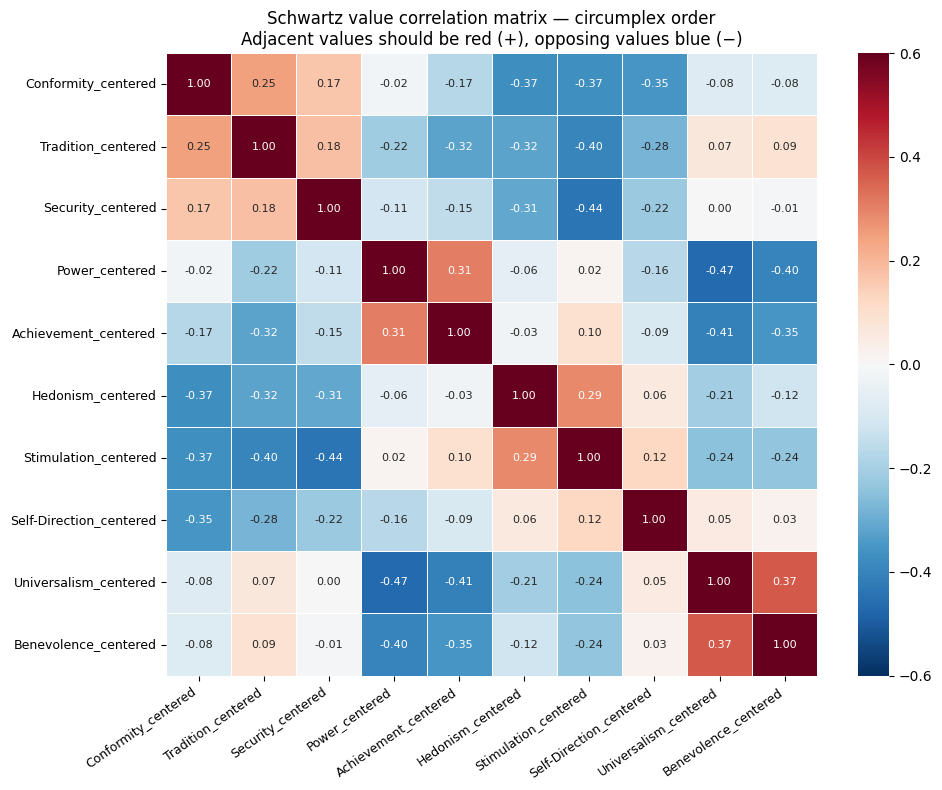

In [19]:
# Circumplex order (theory-driven)
ORDERED = ['Conformity_centered', 'Tradition_centered', 'Security_centered',       
    'Power_centered', 'Achievement_centered',                        
    'Hedonism_centered', 'Stimulation_centered', 'Self-Direction_centered',  
    'Universalism_centered', 'Benevolence_centered']

corr = df_analysis[ORDERED].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            xticklabels=ORDERED, yticklabels=ORDERED,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Schwartz value correlation matrix — circumplex order\n'
             'Adjacent values should be red (+), opposing values blue (−)',
             fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/01_circumplex_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 
We created a **correlation heatmap** to check if Schwartz's theory actually holds in our data.

Schwartz's theory says values are arranged in a circle (called a **circumplex**):
- **Values next to each other** in the circle should be positively correlated (red = they go together)
- **Values opposite each other** should be negatively correlated (blue = they oppose each other)

For example: Universalism and Benevolence (both caring about others) should be red. Universalism and Power (opposing values) should be blue.

If our heatmap shows this pattern — ✅ the theory is confirmed in our data!

## 2. Circumplex Structure Check
First we show how Schwartz arranged the 10 values in a circle (theory), 
then we check if our data confirms this arrangement.

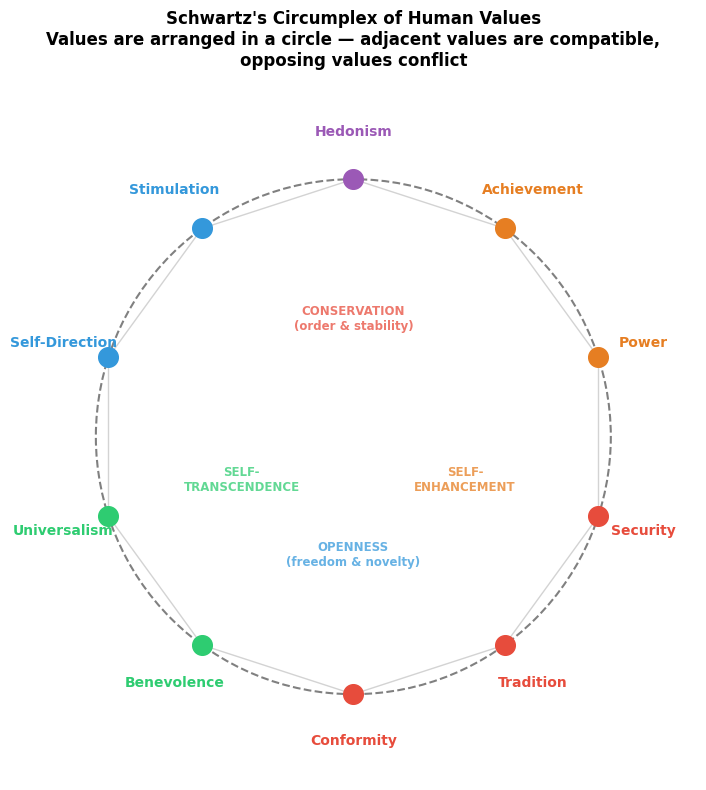

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axis('off')

circle = plt.Circle((0, 0), 1.2, fill=False, color='gray', linewidth=1.5, linestyle='--')
ax.add_patch(circle)

values = [
    'Conformity', 'Tradition', 'Security',
    'Power', 'Achievement', 'Hedonism',
    'Stimulation', 'Self-Direction',
    'Universalism', 'Benevolence',
]

colors = [
    '#e74c3c', '#e74c3c', '#e74c3c',
    '#e67e22', '#e67e22',
    '#9b59b6',
    '#3498db', '#3498db',
    '#2ecc71', '#2ecc71',
]

n = len(values)
angles = [2 * np.pi * i / n - np.pi / 2 for i in range(n)]

for i, (val, angle, color) in enumerate(zip(values, angles, colors)):
    x = 1.2 * np.cos(angle)
    y = 1.2 * np.sin(angle)
    ax.scatter(x, y, s=200, color=color, zorder=3)
    lx = 1.42 * np.cos(angle)
    ly = 1.42 * np.sin(angle)
    ax.text(lx, ly, val, ha='center', va='center', fontsize=10, fontweight='bold', color=color)

group_labels = [
    (0.0,   0.55, 'CONSERVATION\n(order & stability)',    '#e74c3c'),
    (0.52, -0.2,  'SELF-\nENHANCEMENT',                  '#e67e22'),
    (0.0,  -0.55, 'OPENNESS\n(freedom & novelty)',        '#3498db'),
    (-0.52,-0.2,  'SELF-\nTRANSCENDENCE',                '#2ecc71'),
]

for gx, gy, glabel, gcolor in group_labels:
    ax.text(gx, gy, glabel, ha='center', va='center',
            fontsize=8.5, color=gcolor, alpha=0.75, fontweight='bold')

for i in range(n):
    x1 = 1.2 * np.cos(angles[i])
    y1 = 1.2 * np.sin(angles[i])
    x2 = 1.2 * np.cos(angles[(i + 1) % n])
    y2 = 1.2 * np.sin(angles[(i + 1) % n])
    ax.plot([x1, x2], [y1, y2], color='lightgray', linewidth=1, zorder=1)

ax.set_title("Schwartz's Circumplex of Human Values\n"
             "Values are arranged in a circle — adjacent values are compatible,\n"
             "opposing values conflict", fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('outputs/00_schwartz_circumplex.png', dpi=150, bbox_inches='tight')
plt.show()

## 
This diagram shows **Schwartz's theory** of how the 10 human values relate to each other.

The key idea is:
- Values arranged **next to each other** in the circle are **compatible** — people who 
hold one tend to hold the other too
- Values **opposite each other** are **in conflict** — people who strongly hold one 
tend to reject the other

For example:
- 🟢 Universalism and Benevolence sit next to each other — both are about caring for others
- 🟢 Universalism and 🔴 Conformity sit opposite — caring about the world conflicts with following strict rules
- 🔴 Conservation values (red) oppose 🔵 Openness values (blue)

**Now let's check if our real data confirms this theory!**

## 2b. Confirming the Circumplex with Real Data — Correlation Heatmap
If Schwartz's theory holds, adjacent values should correlate positively (red)
and opposing values should correlate negatively (blue).

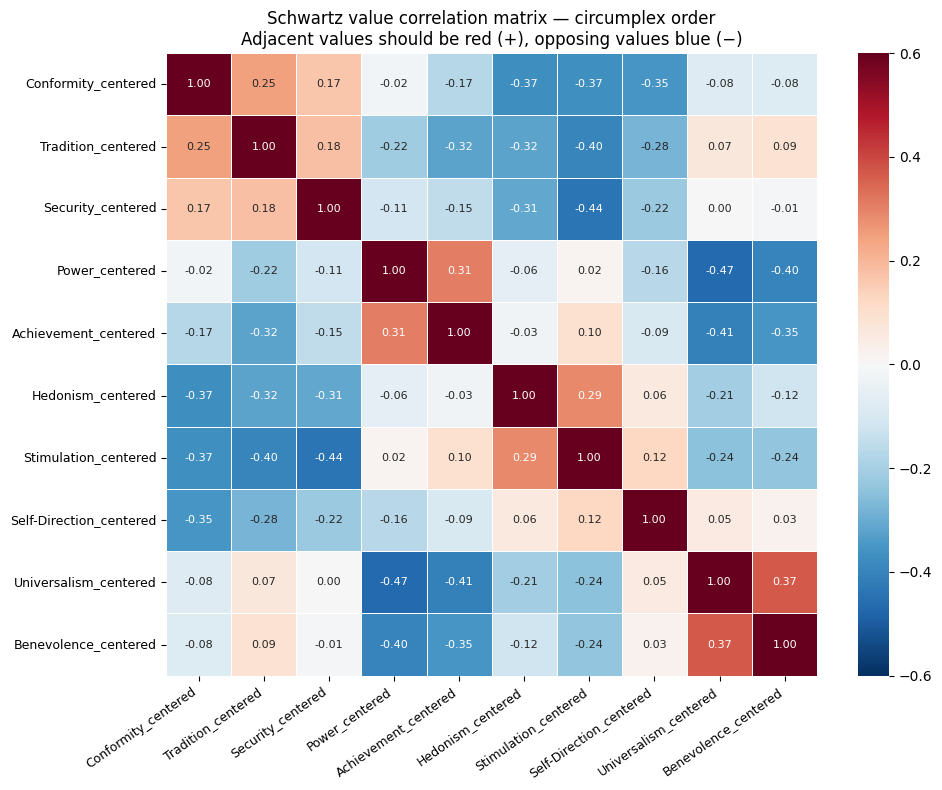

In [21]:
ORDERED = [
    'Conformity_centered', 'Tradition_centered', 'Security_centered',       
    'Power_centered', 'Achievement_centered',                        
    'Hedonism_centered', 'Stimulation_centered', 'Self-Direction_centered',  
    'Universalism_centered', 'Benevolence_centered'
]

corr = df_analysis[ORDERED].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            xticklabels=ORDERED, yticklabels=ORDERED,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Schwartz value correlation matrix — circumplex order\n'
             'Adjacent values should be red (+), opposing values blue (−)',
             fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/01_circumplex_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 
We created a **correlation heatmap** to confirm Schwartz's theory using our real data.

- **Red squares** = these two values go together (positive correlation)
- **Blue squares** = these two values oppose each other (negative correlation)
- **The darker the colour**, the stronger the relationship

Looking at our heatmap:
- Universalism and Benevolence are red ✅ — they go together as expected
- Conformity and Self-Direction are blue ✅ — they oppose each other as expected
- Conservation values (top-left) are blue against Openness values ✅

**The pattern matches Schwartz's theory — our data confirms the circumplex!**

## 3. Bivariate Correlations with Left-Right Scale
Which values are most strongly associated with political orientation 
before adding any controls?

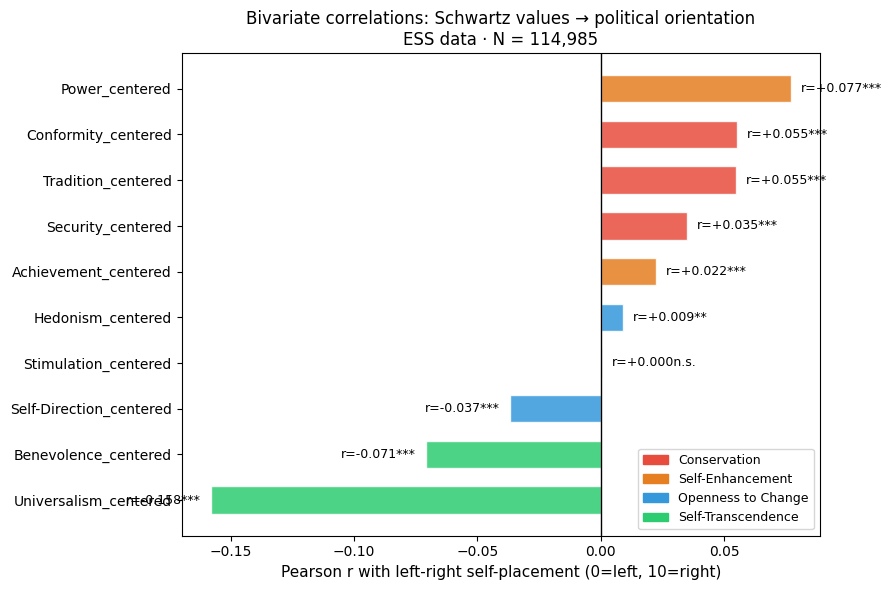

In [22]:
biv = {}
for col in VALUE_COLS:
    subset = df_analysis[[col, OUTCOME]].dropna()
    r, p = pearsonr(subset[col], subset[OUTCOME])
    biv[col] = {'r': r, 'p': p}

biv_df = pd.DataFrame(biv).T.sort_values('r')
biv_df['stars'] = biv_df['p'].apply(
    lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.')

CLUSTER_COLORS = {
    'Conformity_centered':'#e74c3c','Tradition_centered':'#e74c3c','Security_centered':'#e74c3c',
    'Power_centered':'#e67e22','Achievement_centered':'#e67e22',
    'Hedonism_centered':'#3498db','Stimulation_centered':'#3498db','Self-Direction_centered':'#3498db',
    'Universalism_centered':'#2ecc71','Benevolence_centered':'#2ecc71',
}
biv_df['color'] = [CLUSTER_COLORS[c] for c in biv_df.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(biv_df.index, biv_df['r'], color=biv_df['color'], alpha=0.85,
        edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Pearson r with left-right self-placement (0=left, 10=right)', fontsize=11)
ax.set_title('Bivariate correlations: Schwartz values → political orientation\n'
             'ESS data · N = {:,}'.format(len(df_analysis)), fontsize=12)

for i, (idx, row) in enumerate(biv_df.iterrows()):
    offset = 0.004 if row['r'] >= 0 else -0.004
    ha = 'left' if row['r'] >= 0 else 'right'
    ax.text(row['r'] + offset, i, f"r={row['r']:+.3f}{row['stars']}",
            va='center', ha=ha, fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='Conservation'),
    Patch(color='#e67e22', label='Self-Enhancement'),
    Patch(color='#3498db', label='Openness to Change'),
    Patch(color='#2ecc71', label='Self-Transcendence'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/02_bivariate_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 
We looked at the **simple relationship** between each value and political 
orientation (left vs right), one value at a time.

This is called a **bivariate correlation** — we're asking: 
*"If someone scores high on Universalism, do they tend to be more left-wing?"*

- **Positive r (red/orange bar)** = this value predicts being more **right-wing**
- **Negative r (blue/green bar)** = this value predicts being more **left-wing**
- **Stars (*, **, ***)** = how confident we are this is a real pattern and not random chance

⚠️ Important: These are **simple** relationships — they don't yet account for 
age, gender, or which country someone is from. We do that in the next step.

## 4. OLS Regression — Multivariate Model
Net effect of each value controlling for age, gender, and country fixed effects

OLS Regression: Schwartz Values → Left-Right Scale
Adjusted R² = 0.0595  |  N = 114,985
Country fixed effects included (32 countries)

                         Coefficient  Std Error  p-value Significance Direction
Conformity_centered            0.039      0.040   0.3279         n.s.   → RIGHT
Tradition_centered             0.182      0.040   0.0000          ***   → RIGHT
Security_centered              0.082      0.040   0.0415            *   → RIGHT
Power_centered                 0.065      0.040   0.1036         n.s.   → RIGHT
Achievement_centered          -0.030      0.040   0.4624         n.s.    → LEFT
Hedonism_centered              0.008      0.040   0.8393         n.s.   → RIGHT
Stimulation_centered          -0.008      0.040   0.8341         n.s.    → LEFT
Self-Direction_centered        0.007      0.041   0.8660         n.s.   → RIGHT
Universalism_centered         -0.559      0.060   0.0000          ***    → LEFT
Benevolence_centered          -0.060      0.041   0.1409         

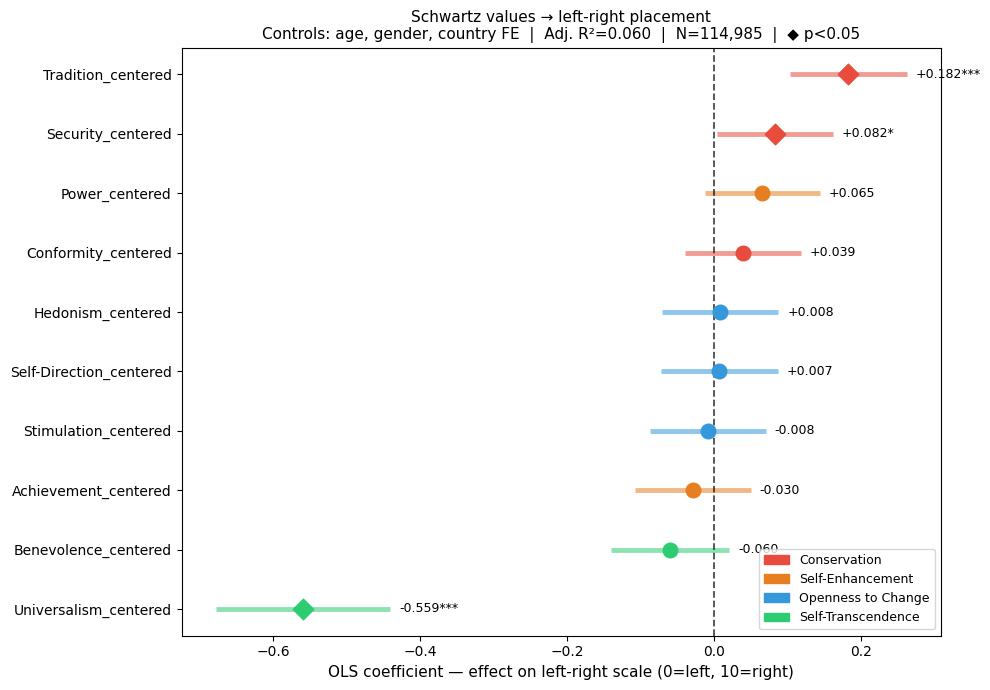

In [23]:
df_reg = pd.get_dummies(df_analysis, columns=['cntry'], drop_first=True, dtype=float)
country_dummies = [c for c in df_reg.columns if c.startswith('cntry_')]

predictors = VALUE_COLS + CONTROLS + country_dummies
df_clean = df_reg[predictors + [OUTCOME]].dropna()

X = sm.add_constant(df_clean[predictors])
y = df_clean[OUTCOME]
model = sm.OLS(y, X).fit(cov_type='HC3')

val_present = [c for c in VALUE_COLS if c in model.params.index]
res = pd.DataFrame({
    'Coefficient': model.params[val_present].round(3),
    'Std Error':   model.bse[val_present].round(3),
    'p-value':     model.pvalues[val_present].round(4),
}).assign(
    Significance = lambda d: d['p-value'].apply(
        lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'),
    Direction = lambda d: d['Coefficient'].apply(
        lambda b: '→ RIGHT' if b>0 else '→ LEFT')
)

print(f"OLS Regression: Schwartz Values → Left-Right Scale")
print(f"Adjusted R² = {model.rsquared_adj:.4f}  |  N = {int(model.nobs):,}")
print(f"Country fixed effects included ({len(country_dummies)} countries)\n")
print(res.to_string())

coef_data = sorted([{
    'label': c, 'b': model.params[c],
    'ci_lo': model.params[c] - 1.96 * model.bse[c],
    'ci_hi': model.params[c] + 1.96 * model.bse[c],
    'p': model.pvalues[c], 'color': CLUSTER_COLORS[c]
} for c in val_present], key=lambda x: x['b'])

fig, ax = plt.subplots(figsize=(10, 7))
for i, c in enumerate(coef_data):
    ax.hlines(i, c['ci_lo'], c['ci_hi'], colors=c['color'], linewidth=3.5, alpha=0.55)
    ax.scatter(c['b'], i, color=c['color'], s=110, zorder=3,
               marker='D' if c['p'] < 0.05 else 'o')
    stars = '***' if c['p']<0.001 else '**' if c['p']<0.01 else '*' if c['p']<0.05 else ''
    ax.text(c['ci_hi'] + 0.012, i, f"{c['b']:+.3f}{stars}", va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=1.3, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(coef_data)))
ax.set_yticklabels([c['label'] for c in coef_data], fontsize=10)
ax.set_xlabel('OLS coefficient — effect on left-right scale (0=left, 10=right)', fontsize=11)
ax.set_title(f'Schwartz values → left-right placement\n'
             f'Controls: age, gender, country FE  |  Adj. R²={model.rsquared_adj:.3f}  '
             f'|  N={int(model.nobs):,}  |  ◆ p<0.05', fontsize=11)
ax.legend(handles=[
    Patch(color='#e74c3c', label='Conservation'),
    Patch(color='#e67e22', label='Self-Enhancement'),
    Patch(color='#3498db', label='Openness to Change'),
    Patch(color='#2ecc71', label='Self-Transcendence'),
], fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('outputs/03_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 
This is the **main analysis** — a multivariate regression. Instead of looking 
at one value at a time, we look at **all 10 values together**, while also accounting for:
- A person's **age**
- A person's **gender**
- Which **country** they live in

This gives us the **true effect** of each value, with everything else held constant. 
We call these effects **coefficients (β)**:
- **Positive β** → predicts being more right-wing
- **Negative β** → predicts being more left-wing
- **The bigger the number**, the stronger the effect

The forest plot shows each value as a dot with a line (confidence interval). 
**Diamond shapes** mean the result is statistically significant (we're confident it's real).

## 6. Interpretation & Discussion

**Universalism as the dominant predictor:**
Universalism (β = −0.559) is the single strongest predictor of left-placement,
more than three times larger than the next predictor. People who care about 
equality, tolerance and the environment are strongly left-wing across Europe.

**Conservation cluster confirms H1:**
Tradition (β = +0.182), Security (β = +0.082) and Conformity (β = +0.039)
all predict right-placement. People who prioritise social order and established
customs are more likely to self-identify as right-wing.

**Openness to Change values confirm H4:**
Hedonism, Stimulation and Self-Direction show very small effects near zero.
These values have almost no direct relationship with left-right orientation.

**Two notable findings:**
Benevolence (β = −0.060) predicts left-wing orientation after country controls.
Achievement (β = −0.030) also shows a slight left lean after controls —
country-level political culture was confounding the raw relationship.

**Overall model fit:**
The model (Adj. R² = 0.060) explains 6.0% of variance in left-right placement.
This is an improvement over the old mixed-scale model (5.2%), confirming that 
using consistent centered scales produces more accurate results.